In [ ]:
#! pip install faostat
# https://pypi.org/project/faostat/
! pip install --upgrade faostat

In [ ]:
import faostat
import pandas as pd
import numpy as np
from google.colab import userdata
import requests
import matplotlib.pyplot as plt
import seaborn as sns

## Food Security

### World Totals/ Overview

In [ ]:
mytimeout = 360
faostat.set_requests_args(username=userdata.get('faostat_user'), password=userdata.get('faostat_pwd'), timeout=mytimeout)


In [ ]:
datasets = faostat.list_datasets_df()
datasets.head()

,code,label,date_update,note_update,release_current,state_current,year_current,release_next,state_next,year_next
0,QCL,Crops and livestock products,2025-12-31,,2025-12-31,final,2024,2026-12,final,2025
1,QI,Production Indices,2026-05-11,,2026-05-11,final,2024,2027-02,final,2025
2,QV,Value of Agricultural Production,2026-05-11,,2026-05-11,final,2024,2027-02,final,2025
3,FS,Suite of Food Security Indicators,2026-07-21,,2026-07-21,final,2025,2027-07,final,2026
4,FBS,Food Balances (2010-),2025-10-28,,2025-10-28,final,2023,2026-10,final,2024


In [ ]:
desired_label = "Cost and Affordability of a Healthy Diet (CoAHD)"
desired_code = datasets[datasets['label'] == desired_label]['code'].values[0]
display(desired_code)

'CAHD'

In [ ]:
ssa_countries = pd.read_csv(r"/content/subsahran_africa_countries.csv", encoding="cp1252")
countries = ssa_countries["Country"]

Requests should only be made for a subset of the dataset. Requesting the full dataset will fail.

In [ ]:
faostat.list_pars_df(desired_code)

,parameter code,coding_systems,subdimensions {code: meaning}
0,area,"[M49, FAO, ISO2, ISO3]","{'countries': 'Countries', 'regions': 'Regions..."
1,element,[],{'elements': 'Elements'}
2,item,[],{'items': 'Items'}
3,year,[],{'years': 'Years'}
4,release,[],{'releases': 'Release'}


In [ ]:
areas = faostat.get_par_df(desired_code, 'area')
areas.head()
area_codes = areas[areas['label'].isin(countries)]["code"]

In [ ]:
cahd = faostat.get_data_df(desired_code, pars={'area':area_codes, 'area_cs':'M49'})

In [ ]:
cahd.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Release,Value
0,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),024,Angola,6226,Value,70040,Cost of a healthy diet (CoHD),2017,2017,Int$ (PPP) per person per day,July 2026 (SOFI report),3.18
1,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),024,Angola,6226,Value,70040,Cost of a healthy diet (CoHD),2018,2018,Int$ (PPP) per person per day,July 2026 (SOFI report),3.27
2,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),024,Angola,6226,Value,70040,Cost of a healthy diet (CoHD),2019,2019,Int$ (PPP) per person per day,July 2026 (SOFI report),3.43
3,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),024,Angola,6226,Value,70040,Cost of a healthy diet (CoHD),2020,2020,Int$ (PPP) per person per day,July 2026 (SOFI report),3.70
4,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),024,Angola,6226,Value,70040,Cost of a healthy diet (CoHD),2021,2021,Int$ (PPP) per person per day,July 2026 (SOFI report),4.11


In [ ]:
cahd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2256 entries, 0 to 2255
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Domain Code      2256 non-null   object
 1   Domain           2256 non-null   object
 2   Area Code (M49)  2256 non-null   object
 3   Area             2256 non-null   object
 4   Element Code     2256 non-null   object
 5   Element          2256 non-null   object
 6   Item Code        2256 non-null   object
 7   Item             2256 non-null   object
 8   Year Code        2256 non-null   object
 9   Year             2256 non-null   object
 10  Unit             2256 non-null   object
 11  Release          2256 non-null   object
 12  Value            2142 non-null   object
dtypes: object(13)
memory usage: 229.3+ KB


In [ ]:
cahd.describe()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Release,Value
count,2256,2256,2256,2256,2256,2256,2256,2256,2256,2256,2256,2256,2142
unique,1,1,47,47,4,1,16,9,9,9,4,1,1435
top,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),024,Angola,6226,Value,70040,Cost of a healthy diet (CoHD),2021,2021,Int$ (PPP) per person per day,July 2026 (SOFI report),0.1
freq,2256,2256,48,48,705,2256,423,846,752,752,705,2256,17


In [ ]:
cahd.Item.unique()

array(['Cost of a healthy diet (CoHD)', 'Cost of starchy staples',
       'Cost of animal source foods', 'Cost of legumes, nuts and seeds',
       'Cost of vegetables', 'Cost of fruits', 'Cost of oils and fats',
       'Prevalence of unaffordability (PUA)',
       'Number of people unable to afford a healthy diet (NUA)'],
      dtype=object)

In [ ]:
cahd.Element.unique()

array(['Value'], dtype=object)

In [ ]:
cahd["Year Code"].unique()

array(['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'], dtype=object)

In [ ]:
cahd.Unit.unique()

array(['Int$ (PPP) per person per day', 'LCU/cap/d', '%', 'million No'],
      dtype=object)

According to the data portal this dataset three main items (Cost of a Healthy Diet, Prevelance of Unaffordability (PUA), and Number of people unable to afford a health diet (NUA)) with other items being subsets of CoAHD.
The Dataset contains data for 2017-2025.

## Transforming the Dataset

In [ ]:
# rows identified by country and year with items+unit columns becoming columns and Value as the values
cahd_wide = (
    cahd.assign(
        Year=pd.to_numeric(cahd["Year"], errors="coerce").astype("Int64"),
        Value=pd.to_numeric(cahd["Value"], errors="coerce"),
        item_unit=(
            cahd["Item"].str.strip()
            + " ("
            + cahd["Unit"].str.strip().str.replace("Int$ (PPP)","$")
            + ")"
        )
    )
    .pivot(
        index=["Area", "Year"],
        columns="item_unit",
        values="Value"
    )
    .reset_index()
    .rename_axis(columns=None)
)

cahd_wide.head(10)

,Area,Year,Cost of a healthy diet (CoHD) ($ per person per day),Cost of a healthy diet (CoHD) (LCU/cap/d),Cost of animal source foods ($ per person per day),Cost of animal source foods (LCU/cap/d),Cost of fruits ($ per person per day),Cost of fruits (LCU/cap/d),"Cost of legumes, nuts and seeds ($ per person per day)","Cost of legumes, nuts and seeds (LCU/cap/d)",Cost of oils and fats ($ per person per day),Cost of oils and fats (LCU/cap/d),Cost of starchy staples ($ per person per day),Cost of starchy staples (LCU/cap/d),Cost of vegetables ($ per person per day),Cost of vegetables (LCU/cap/d),Number of people unable to afford a healthy diet (NUA) (million No),Prevalence of unaffordability (PUA) (%)
0,Angola,2017,3.18,368.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.2,60.1
1,Angola,2018,3.27,427.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.3,64.8
2,Angola,2019,3.43,498.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.6,66.8
3,Angola,2020,3.70,633.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.3,69.6
4,Angola,2021,4.11,836.22,1.15,234.41,0.75,152.35,0.42,84.72,0.21,41.79,1.15,233.78,0.44,89.17,24.5,71.1
5,Angola,2022,4.55,1041.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.4,71.4
6,Angola,2023,4.72,1178.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.4,71.8
7,Angola,2024,5.00,1554.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.4,72.2
8,Angola,2025,5.18,1886.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.4,72.9
9,Benin,2017,2.85,613.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.6,80.1


In [ ]:
cahd_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 18 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Area                                                                 423 non-null    object 
 1   Year                                                                 423 non-null    Int64  
 2   Cost of a healthy diet (CoHD) ($ per person per day)                 396 non-null    float64
 3   Cost of a healthy diet (CoHD) (LCU/cap/d)                            414 non-null    float64
 4   Cost of animal source foods ($ per person per day)                   44 non-null     float64
 5   Cost of animal source foods (LCU/cap/d)                              46 non-null     float64
 6   Cost of fruits ($ per person per day)                                44 non-null     float64
 7   Cost of 

In [ ]:
cahd_wide[(cahd_wide['Number of people unable to afford a healthy diet (NUA) (million No)'].isna())|(cahd_wide['Prevalence of unaffordability (PUA) (%)'].isna())|(cahd_wide['Cost of a healthy diet (CoHD) ($ per person per day)'].isna())]

,Area,Year,Cost of a healthy diet (CoHD) ($ per person per day),Cost of a healthy diet (CoHD) (LCU/cap/d),Cost of animal source foods ($ per person per day),Cost of animal source foods (LCU/cap/d),Cost of fruits ($ per person per day),Cost of fruits (LCU/cap/d),"Cost of legumes, nuts and seeds ($ per person per day)","Cost of legumes, nuts and seeds (LCU/cap/d)",Cost of oils and fats ($ per person per day),Cost of oils and fats (LCU/cap/d),Cost of starchy staples ($ per person per day),Cost of starchy staples (LCU/cap/d),Cost of vegetables ($ per person per day),Cost of vegetables (LCU/cap/d),Number of people unable to afford a healthy diet (NUA) (million No),Prevalence of unaffordability (PUA) (%)
342,Somalia,2017,NaN,1.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343,Somalia,2018,NaN,1.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
344,Somalia,2019,NaN,1.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
345,Somalia,2020,NaN,1.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
346,Somalia,2021,NaN,1.63,NaN,0.51,NaN,0.14,NaN,0.29,NaN,0.09,NaN,0.28,NaN,0.31,NaN,NaN
347,Somalia,2022,NaN,1.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
348,Somalia,2023,NaN,1.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
349,Somalia,2024,NaN,1.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
350,Somalia,2025,NaN,1.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
369,Sudan,2017,NaN,14.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Somalia, Sudan, and Zimbabwe are mising either all or more than half of the data for the year. If data is missing for one of the columns being checked here it is missing from all three.

In [ ]:
missing_data_countries = cahd_wide[(cahd_wide['Number of people unable to afford a healthy diet (NUA) (million No)'].isna())|(cahd_wide['Prevalence of unaffordability (PUA) (%)'].isna())|(cahd_wide['Cost of a healthy diet (CoHD) ($ (PPP) per person per day)'].isna())].Area.unique()

In [ ]:
cahd_wide[(cahd_wide['Cost of a healthy diet (CoHD) (LCU/cap/d)'].isna())&(~cahd_wide['Area'].isin(missing_data_countries))]

,Area,Year,Cost of a healthy diet (CoHD) ($ per person per day),Cost of a healthy diet (CoHD) (LCU/cap/d),Cost of animal source foods ($ per person per day),Cost of animal source foods (LCU/cap/d),Cost of fruits ($ per person per day),Cost of fruits (LCU/cap/d),"Cost of legumes, nuts and seeds ($ per person per day)","Cost of legumes, nuts and seeds (LCU/cap/d)",Cost of oils and fats ($ per person per day),Cost of oils and fats (LCU/cap/d),Cost of starchy staples ($ per person per day),Cost of starchy staples (LCU/cap/d),Cost of vegetables ($ per person per day),Cost of vegetables (LCU/cap/d),Number of people unable to afford a healthy diet (NUA) (million No),Prevalence of unaffordability (PUA) (%)


In [ ]:
cahd_final = cahd_wide[["Area","Year","Cost of a healthy diet (CoHD) ($ per person per day)","Cost of a healthy diet (CoHD) (LCU/cap/d)", "Number of people unable to afford a healthy diet (NUA) (million No)", "Prevalence of unaffordability (PUA) (%)" ]]
cahd_final.to_csv("SSA_CoAHD_dataset.csv")

## Data Exploration

### Cost of a healthy diet over time for countries in Subsaharan Africa as classified by UNICEF

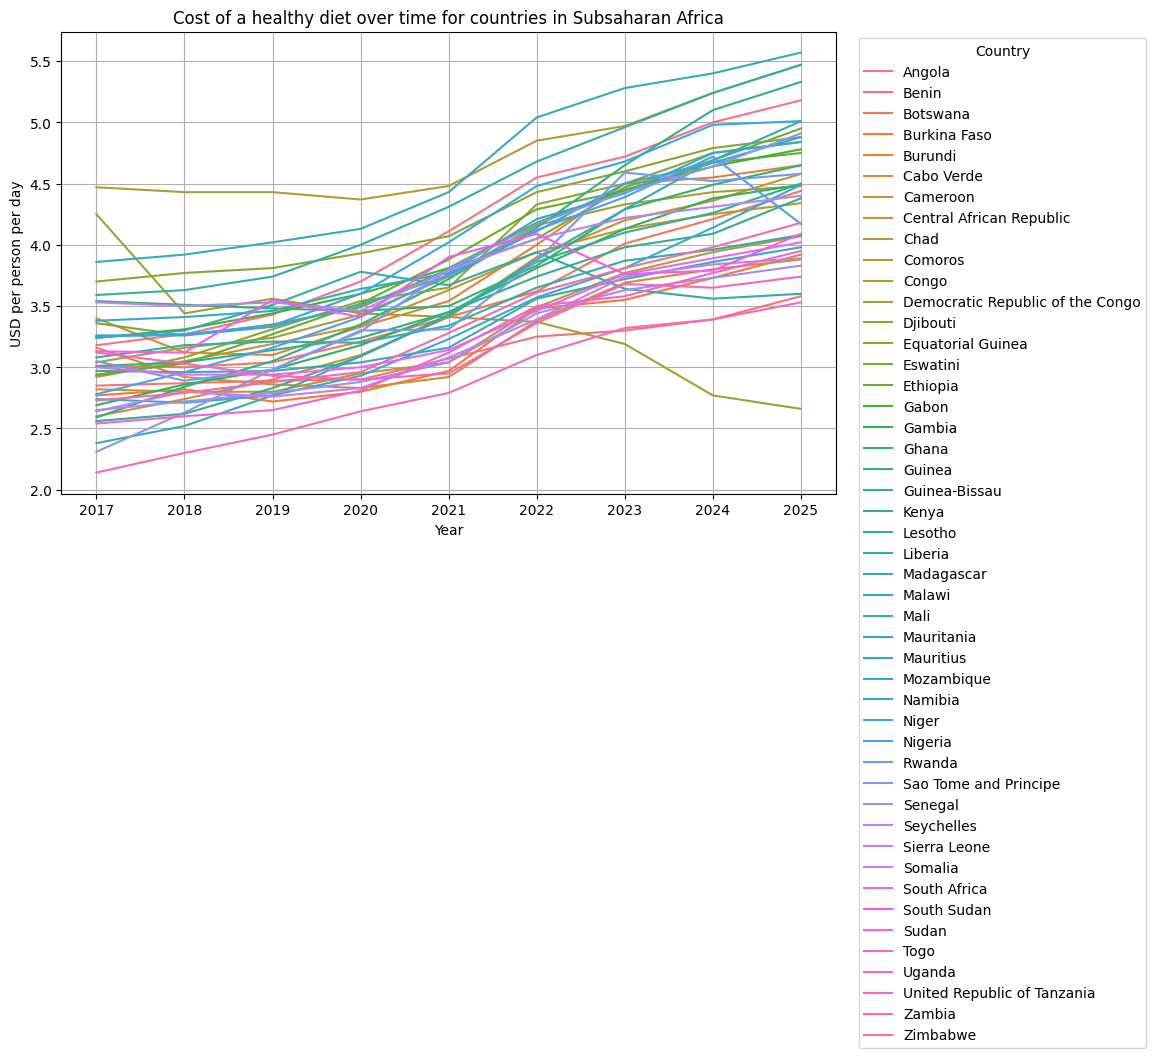

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=cahd_wide, x='Year', y='Cost of a healthy diet (CoHD) ($ per person per day)', hue='Area')
ax.legend(
    title="Country",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.title('Cost of a healthy diet over time for countries in Subsaharan Africa')
plt.xlabel('Year')
plt.ylabel('USD per person per day')
plt.grid(True)
plt.show()

In [ ]:
most_expensive_country = cahd_wide[cahd_wide['Cost of a healthy diet (CoHD) ($ per person per day)']==cahd_wide['Cost of a healthy diet (CoHD) ($ per person per day)'].max()]
most_expensive_ppp_anual_cost = round(most_expensive_country['Cost of a healthy diet (CoHD) ($ per person per day)'].values[0] * 365, 2)
print(f"Cost of food per person per year in the most exspensive country in the subsaharan africa dataset({most_expensive_country["Area"].values[0]}): USD ${most_expensive_ppp_anual_cost}")
print(f"Cost to buy food for all food insecure people in {most_expensive_country['Area'].values[0]} for a year: USD ${round(most_expensive_country["Number of people unable to afford a healthy diet (NUA) (million No)"].values[0] *1000000 * most_expensive_ppp_anual_cost, 2)}")

Cost of food per person per year in the most exspensive country in the subsaharan africa dataset(Mauritania): USD $2033.05
Cost to buy food for all food insecure people in Mauritania for a year: USD $5489235000.0


In [ ]:
#countries where the cost of a healthy diet have fallen between 2017 and 2025


### Number of people unable to afford a healthy diet over time

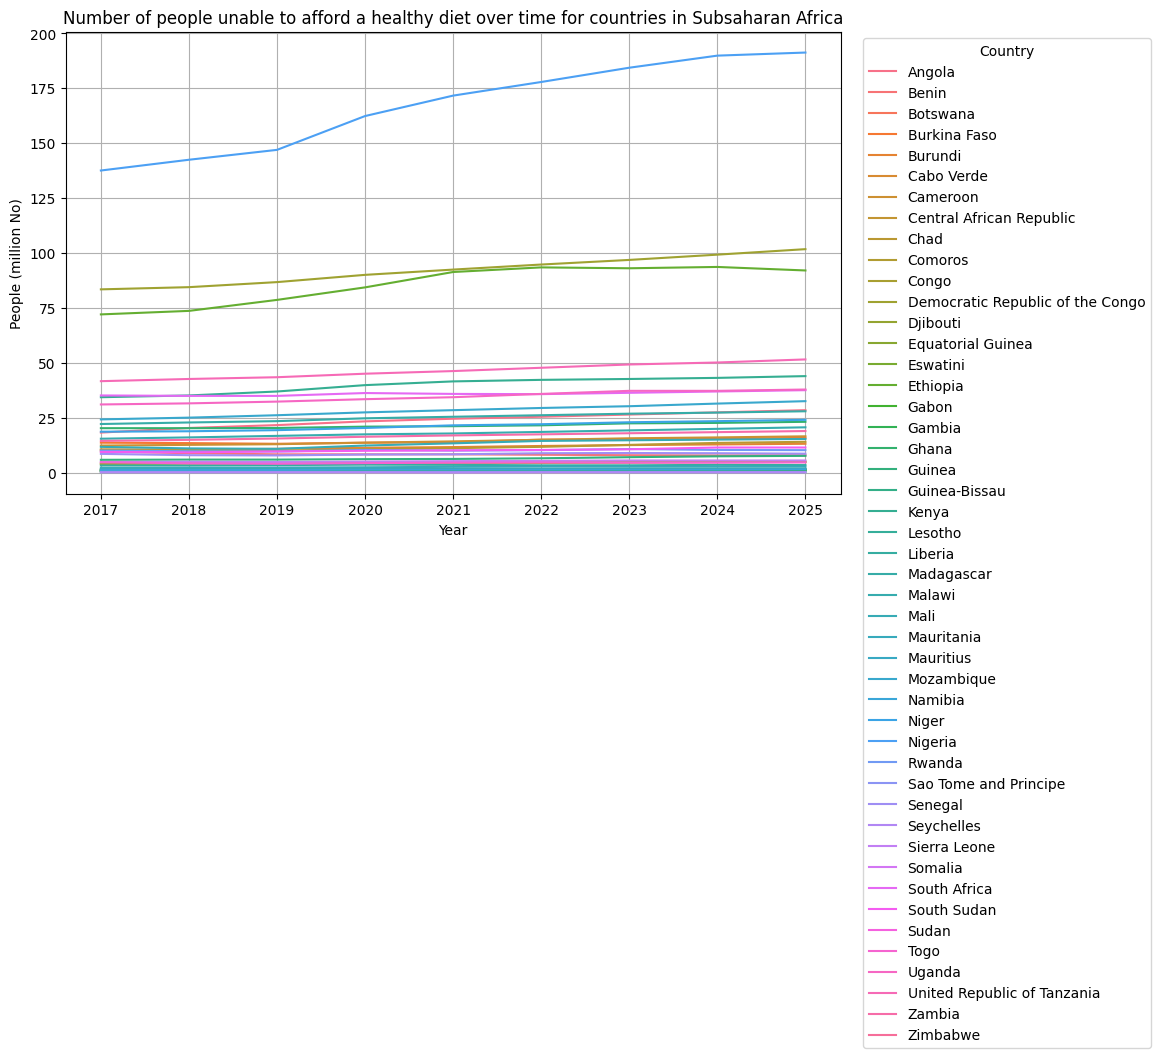

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=cahd_wide, x='Year', y='Number of people unable to afford a healthy diet (NUA) (million No)', hue='Area')
ax.legend(
    title="Country",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.title('Number of people unable to afford a healthy diet over time for countries in Subsaharan Africa')
plt.xlabel('Year')
plt.ylabel('People (million No)')
plt.grid(True)
plt.show()

In [ ]:
column = "Number of people unable to afford a healthy diet (NUA) (million No)"

most_insecure_countries = cahd_wide[cahd_wide['Year'] == 2025].nlargest(3, column)
print(f"Most insecure countries in the subsaharan africa dataset: {most_insecure_countries['Area'].values}")


Most insecure countries in the subsaharan africa dataset: ['Nigeria' 'Democratic Republic of the Congo' 'Ethiopia']


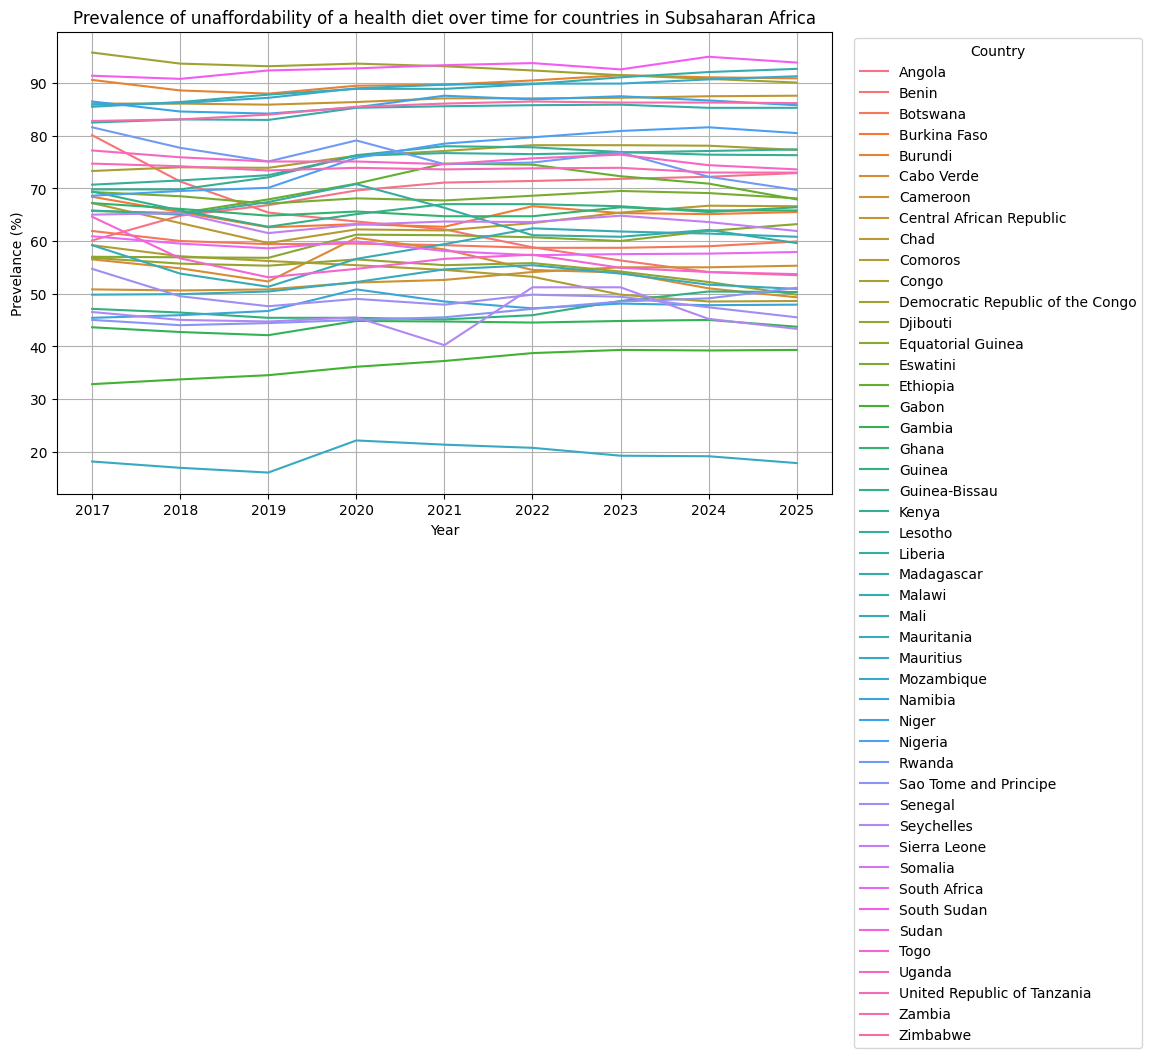

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=cahd_wide, x='Year', y='Prevalence of unaffordability (PUA) (%)', hue='Area')
ax.legend(
    title="Country",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.title('Prevalence of unaffordability of a health diet over time for countries in Subsaharan Africa')
plt.xlabel('Year')
plt.ylabel('Prevelance (%)')
plt.grid(True)
plt.show()

In [ ]:
column = "Prevalence of unaffordability (PUA) (%)"

most_insecure_countries = cahd_wide[cahd_wide['Year'] == 2025].nlargest(5, column)
print(f"Most % insecure countries in the subsaharan africa dataset: {most_insecure_countries['Area'].values}")


Most % insecure countries in the subsaharan africa dataset: ['South Sudan' 'Malawi' 'Mozambique' 'Burundi'
 'Democratic Republic of the Congo']
